# 02 - Corpus EDA: what does the chunked 10-K corpus look like?

Before trusting retrieval numbers, look at the corpus: how big are chunks, how much of it is
tables, which Items dominate, and where the section splitter struggles.

*Skills shown: exploratory data analysis, text statistics, pandas.*

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

import pyarrow.parquet as pq
df = pq.read_table("data/processed/chunks.parquet").to_pandas()
print(f"{len(df):,} chunks from {df.accession.nunique()} filings, {df.ticker.nunique()} companies")
print(f"text chunks {(df.chunk_type=='text').sum():,}   table chunks {(df.chunk_type=='table').sum():,}")

23,221 chunks from 60 filings, 12 companies
text chunks 14,149   table chunks 9,072


## 1. Chunk size (regex tokens)

Text chunks target 400 tokens; tables are kept whole up to 2x that. Small text chunks are captions and short sections that survived.

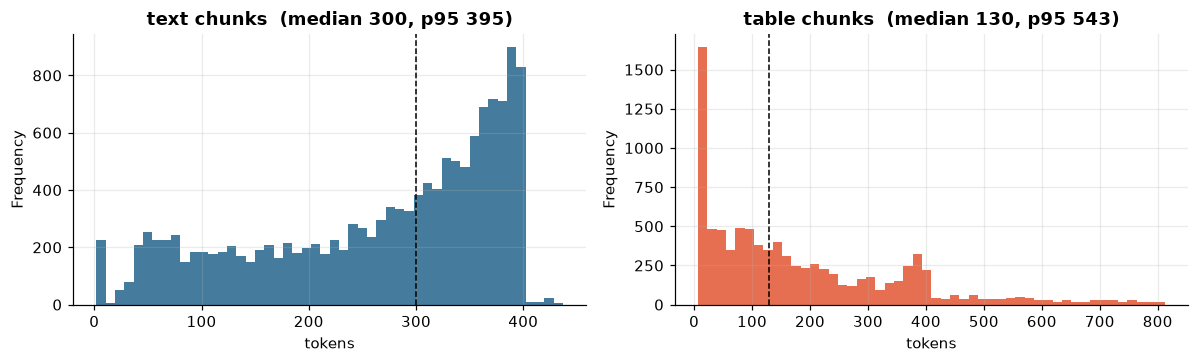

              count   mean    std  min    25%    50%    75%    max
chunk_type                                                        
table        9072.0  183.0  172.0  7.0   44.0  130.0  285.0  812.0
text        14149.0  265.0  114.0  2.0  179.0  300.0  363.0  437.0


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=False)
for ax, (kind, color) in zip(axes, [("text", "#457b9d"), ("table", "#e76f51")]):
    d = df[df.chunk_type == kind].token_count
    d.plot.hist(bins=50, ax=ax, color=color)
    ax.axvline(d.median(), color="k", ls="--", lw=1)
    ax.set_title(f"{kind} chunks  (median {int(d.median())}, p95 {int(d.quantile(.95))})"); ax.set_xlabel("tokens")
plt.tight_layout(); plt.show()
print(df.groupby('chunk_type').token_count.describe().round(0).to_string())

## 2. Which Items hold the text?

,chunks,tokens,% table chunks,% of all tokens
item,,,,
15,6938,1453951,55.0,26.9
8,6207,1412870,46.0,26.1
1A,2464,754898,5.0,14.0
7,2431,593080,28.0,11.0
16,1686,406205,57.0,7.5
1,1312,393839,10.0,7.3
2,337,81671,44.0,1.5
7A,253,64928,28.0,1.2
5,228,37486,41.0,0.7


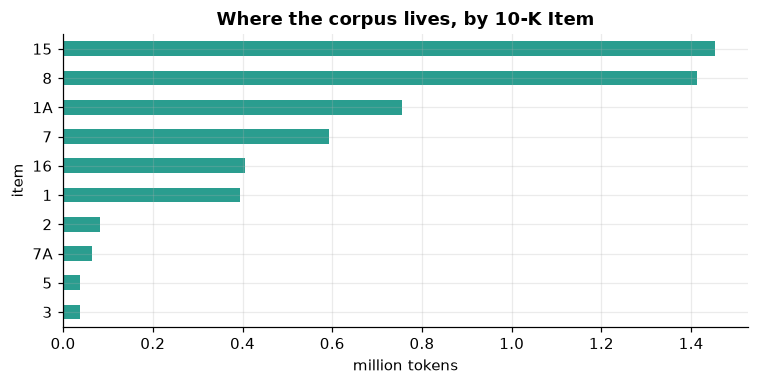

In [3]:
by_item = df.groupby("item").agg(chunks=("id", "size"), tokens=("token_count", "sum"), tables=("chunk_type", lambda s: (s == "table").mean()))
by_item["share_of_tokens"] = by_item.tokens / by_item.tokens.sum()
top = by_item.sort_values("tokens", ascending=False).head(10)
display(top.assign(share_of_tokens=(top.share_of_tokens * 100).round(1), tables=(top.tables * 100).round(0)).rename(columns={"tables": "% table chunks", "share_of_tokens": "% of all tokens"}))
ax = (top.tokens[::-1] / 1e6).plot.barh(figsize=(7, 3.6), color="#2a9d8f")
ax.set_xlabel("million tokens"); ax.set_title("Where the corpus lives, by 10-K Item")
plt.tight_layout(); plt.show()

## 3. Company by company: an anomaly worth understanding

JPMorgan's 10-K is structured differently: Items 7 and 8 are short cross-references, and the MD&A and financial statements sit in an appended annual report that falls under **Item 15**.

In [4]:
per = df.groupby("ticker").agg(chunks=("id", "size"), tables=("chunk_type", lambda s: (s == "table").mean()))
per["chunks_per_filing"] = (per.chunks / df.groupby("ticker").accession.nunique()).round(0)
display(per.assign(tables=(per.tables * 100).round(0)).rename(columns={"tables": "% table chunks"}).sort_values("chunks", ascending=False))
jpm = df[df.ticker == "JPM"].groupby("item").token_count.sum().sort_values(ascending=False)
print("JPM tokens by Item:", (jpm / jpm.sum()).round(3).head(4).to_dict())
print("=> ~%.0f%% of JPM's text is filed under Item 15, so 'Item 7' filters alone would miss its MD&A (documented in docs/LIMITATIONS.md)." % (100 * jpm.get('15', 0) / jpm.sum()))

,chunks,% table chunks,chunks_per_filing
ticker,,,
JPM,6427,48.0,1285.0
KO,2269,31.0,454.0
JNJ,1930,37.0,386.0
XOM,1875,47.0,375.0
GOOGL,1840,46.0,368.0
TSLA,1572,28.0,314.0
MSFT,1442,44.0,288.0
WMT,1426,30.0,285.0
PG,1266,34.0,253.0


JPM tokens by Item: {'15': 0.872, '1A': 0.085, '1': 0.032, '10': 0.003}
=> ~87% of JPM's text is filed under Item 15, so 'Item 7' filters alone would miss its MD&A (documented in docs/LIMITATIONS.md).


## 4. What the retriever actually indexes

Every chunk's indexed text is prefixed with a contextual header so near-identical boilerplate from different companies stays distinguishable.

In [5]:
ex = df[(df.ticker == "AAPL") & (df.item == "7") & (df.fiscal_year == 2024)].iloc[2]
print(ex.embed_text[:600])
print("\n--- header stripped (what the LLM reads) ---\n" + ex.text[:300])

Apple Inc. (AAPL) | 10-K FY2024 | Item 7 - Management's Discussion and Analysis of Financial Condition and Results of Operations | Table
The following table shows net sales by reportable segment for 2024, 2023 and 2022 (dollars in millions):
| 2024 | Change | 2023 | Change | 2022 |
| Americas | $167,045 | 3% | $162,560 | (4)% | $169,658 |
| Europe | 101,328 | 7% | 94,294 | (1)% | 95,118 |
| Greater China | 66,952 | (8)% | 72,559 | (2)% | 74,200 |
| Japan | 25,052 | 3% | 24,257 | (7)% | 25,977 |
| Rest of Asia Pacific | 30,658 | 4% | 29,615 | 1% | 29,375 |
| Total net sales | $391,035 | 2% | $3

--- header stripped (what the LLM reads) ---
The following table shows net sales by reportable segment for 2024, 2023 and 2022 (dollars in millions):
| 2024 | Change | 2023 | Change | 2022 |
| Americas | $167,045 | 3% | $162,560 | (4)% | $169,658 |
| Europe | 101,328 | 7% | 94,294 | (1)% | 95,118 |
| Greater China | 66,952 | (8)% | 72,559 | (2


## Findings

* Text chunks stay within the budget (see the histogram and the table above); tables are a large
  minority of chunks, which is why retrieval is evaluated **per chunk type**.
* The Item table above shows where the volume sits: the financial-statement Items are large but are
  mostly tables, while risk factors and MD&A are prose - the parts questions tend to be about.
* Bank filings need special handling: the JPM share printed above is measured, not assumed.